In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import torch

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
import importlib, src.ddm.ddm_simple
importlib.reload(src.ddm.ddm_simple)

<module 'src.ddm.ddm_simple' from '/src/src/ddm/ddm_simple.py'>

In [3]:
COHERENCES     = np.array([-0.50, -0.18, -0.09, 0.0, 0.09, 0.18, 0.50]).round(2)
TRIALS_PER_COH = 150
MAX_DURATION     = 3.0
DT               = 0.001
CAF_WEIGHT       = 1
CAF_BINS = 15

In [4]:
def plot_mean_data(data):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cohs_sorted = sorted(data["coherence"].unique())

    # Psychometric function
    p_upper = []
    for coh in cohs_sorted:
        subset = data[data["coherence"] == coh].dropna()
        p_upper.append((subset["choice"] == 1).mean())

    axes[0].plot(cohs_sorted, p_upper, "o-", color="steelblue")
    axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_xlabel("Coherence")
    axes[0].set_ylabel("P(upper boundary)")
    axes[0].set_title("Psychometric Function")
    axes[0].set_ylim(0, 1)

    # Chronometric function
    mean_rt  = []
    sem_rt   = []
    for coh in cohs_sorted:
        subset = data[data["coherence"] == coh].dropna()
        mean_rt.append(subset["rt"].mean())
        sem_rt.append(subset["rt"].sem())

    axes[1].errorbar(cohs_sorted, mean_rt, yerr=sem_rt, fmt="o-", color="tomato", capsize=4)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_xlabel("Coherence")
    axes[1].set_ylabel("Mean RT (s)")
    axes[1].set_title("Chronometric Function")

    plt.tight_layout()
    plt.show()

# for each coherence plot histogram of RTs for choice 0 and choice 1
def plot_raw_data(data):

    fig, axes = plt.subplots(len(data["coherence"].unique()), 1, figsize=(8, 3 * len(data["coherence"].unique())))

    for ax, coh in zip(axes, sorted(data["coherence"].unique())):
        subset = data[data["coherence"] == coh]
        ax.hist(subset[subset["choice"] == 0]["rt"], bins=20, alpha=0.5, label="choice 0", color="steelblue")
        ax.hist(subset[subset["choice"] == 1]["rt"], bins=20, alpha=0.5, label="choice 1", color="tomato")
        ax.set_title(f"Coherence: {coh:+.2f}")
        ax.set_xlabel("RT (s)")
        ax.set_ylabel("Count")
        ax.set_xlim(0, data["rt"].max() + 0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [5]:
from src.ddm.ddm_simple import DecisionModel, ParamSpec, DEFAULT_PARAMS, validate_params

class SimpleModel(DecisionModel):

    @property
    def param_specs(self) -> dict[str, ParamSpec]:
        return {
            "ndt":           ParamSpec(0.2,  (0.1,  1.0)),
            "a":             ParamSpec(2.0,  (0.8,  6.0)),
            "z":             ParamSpec(0.5,  (0.1,  0.9)),
            "drift_gain":    ParamSpec(7.0,  (1.0, 10.0)),
            "drift_offset":  ParamSpec(0.0,  (-5.0, 5.0)),
            "leak_rate":     ParamSpec(0.1,  (0.0,  1.0)),
            "time_constant": ParamSpec(0.0,  (-3.0, 3.0)),
        }

    def _build_params(self, values: np.ndarray, condition_idx=None) -> dict:
        p = dict(DEFAULT_PARAMS)
        for key, val in zip(self.param_specs.keys(), values):
            p[key] = val
        p["variance"] = 1.0  # always fixed
        validate_params(p)
        return p

    def _objective_function(self, values, data, stimulus, n_reps, seed, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6
        result = self._simulate_condition(stimulus, params, n_reps)
        if result is None:
            return 1e6
        return self.likelihood_calc.calculate_likelihood(
            result["rt"], result["choice"],
            np.asarray(data["rt"]), np.asarray(data["choice"]),
            result["coherence"], np.asarray(data["coherence"]),
        )


# Generate Data

In [6]:
from src.ddm.ddm  import DDMParams, DriftDiffusionSimulatorCUDA, ParamSpec, DecisionModel
from src.ddm.ddm_simple import DriftDiffusionSimulatorCUDA as SimpleCUDA, DEFAULT_PARAMS, validate_params

def make_stimulus() -> np.ndarray:
    n_tp = int(MAX_DURATION / DT)
    coh  = np.repeat(COHERENCES, TRIALS_PER_COH)
    return np.tile(coh.reshape(-1, 1), (1, n_tp)).astype(np.float32)

def generate_data(params: DDMParams, trials=TRIALS_PER_COH, max_duration=MAX_DURATION) -> pd.DataFrame:

    stimulus=make_stimulus()

    sim = DriftDiffusionSimulatorCUDA(device="cuda")

    coherences = np.mean(stimulus, axis=1)  # get coherence for each trial (constant across time)
    rt, choice = sim.simulate_trials(stimulus, params=params)

    return pd.DataFrame({
            "coherence": coherences,
            "rt": rt,
            "choice": choice,
        }), stimulus



def generate_data_simple(params: dict = None, trials=TRIALS_PER_COH, max_duration=MAX_DURATION):
    """Like generate_data() but uses the ddm_simple dict-based API."""
    if params is None:
        params = dict(DEFAULT_PARAMS)
    validate_params(params)

    stimulus   = make_stimulus()
    sim        = SimpleCUDA(device="cuda")
    rt, choice = sim.simulate_trials(stimulus, params)

    coherences = stimulus[:, 0]

    return pd.DataFrame({"coherence": coherences, "rt": rt, "choice": choice}), stimulus

In [24]:
# calculate likelihood for original parameters (before fitting) for comparison
original_params = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,

}

stimulus = make_stimulus()

simple_model = SimpleModel()


data = pd.DataFrame(simple_model.simulate(
    stimulus, params=original_params, n_reps=10, seed=0
))

# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()


# data likelihood under original parameters
likelihood = simple_model.likelihood_calc.calculate_likelihood(
    data["rt"], data["choice"],
    data["rt"], data["choice"],
    data["coherence"], data["coherence"],
)

print(f"Data likelihood under original parameters: {likelihood:.1f}")


# print(summary)

# plot_mean_data(data)
# plot_raw_data(data)

INFO:src.ddm.ddm_simple:Initialized SimpleModel | device=CPU


Data likelihood under original parameters: 0.0


# Recovery Trial

In [25]:
from src.ddm.ddm import DDMParams, ParamSpec, DecisionModel, SimResult
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### DDM Simple

In [35]:
from src.ddm.ddm_simple import DecisionModel, ParamSpec, DEFAULT_PARAMS, validate_params

class SimpleModel(DecisionModel):

    @property
    def param_specs(self) -> dict[str, ParamSpec]:
        return {
            "ndt":           ParamSpec(0.2,  (0.1,  1.0)),
            "a":             ParamSpec(2.0,  (0.8,  6.0)),
            "z":             ParamSpec(0.5,  (0.1,  0.9)),
            "drift_gain":    ParamSpec(7.0,  (1.0, 10.0)),
            "drift_offset":  ParamSpec(0.0,  (-5.0, 5.0)),
            "leak_rate":     ParamSpec(0.1,  (0.0,  0.3)),
            # "variance":     ParamSpec(1.0,  (0.5,  2.0)),
            # "time_constant": ParamSpec(0.0,  (-2.0, 2.0)),
        }

    def _build_params(self, values: np.ndarray, condition_idx=None) -> dict:
        p = dict(DEFAULT_PARAMS)
        for key, val in zip(self.param_specs.keys(), values):
            p[key] = val
        p["variance"] = 1.0  # always fixed
        p["time_constant"] = 0.0  # always fixed
        validate_params(p)
        return p

    def _objective_function(self, values, data, stimulus, n_reps, seed, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6
        result = self._simulate_condition(stimulus, params, n_reps)
        if result is None:
            return 1e6
        return self.likelihood_calc.calculate_likelihood(
            result["rt"], result["choice"],
            np.asarray(data["rt"]), np.asarray(data["choice"]),
            result["coherence"], np.asarray(data["coherence"]),
        )


In [36]:
simple_model_cuda = SimpleModel(
    device='cuda',
    likelihood_params={
        "caf_weight": CAF_WEIGHT,
        "caf_bins": CAF_BINS,
        "rt_var_weight": 1.0
        }
)
result_cuda = simple_model_cuda.fit(
    data={"rt": data["rt"], "choice": data["choice"], "coherence": data["coherence"]},
    stimulus=stimulus,
    max_iterations=300,
    n_reps=15,   # more reps = less Monte Carlo noise per evaluation
    l1_weight=0,
)

INFO:src.ddm.ddm_simple:Initialized SimpleModel | device=CPU
INFO:src.ddm.ddm_simple:Starting optimisation (SimpleModel)...
INFO:src.ddm.ddm_simple:Iter   1 | NLL=6616.8264 | convergence=0.0233 | ndt=0.1159  a=1.5094  z=0.1675  drift_gain=5.1753  drift_offset=2.1560  leak_rate=0.1645
INFO:src.ddm.ddm_simple:Iter   2 | NLL=4092.2069 | convergence=0.0175 | ndt=0.1756  a=1.0333  z=0.4629  drift_gain=1.1699  drift_offset=0.5269  leak_rate=0.1708
INFO:src.ddm.ddm_simple:Iter   3 | NLL=3490.6889 | convergence=0.0157 | ndt=0.1262  a=1.1116  z=0.6623  drift_gain=5.1561  drift_offset=-0.6517  leak_rate=0.0882
INFO:src.ddm.ddm_simple:Iter   4 | NLL=1389.2430 | convergence=0.0138 | ndt=0.2372  a=0.8931  z=0.6089  drift_gain=5.7557  drift_offset=-0.7719  leak_rate=0.1137
INFO:src.ddm.ddm_simple:Iter   5 | NLL=1389.2430 | convergence=0.0117 | ndt=0.2372  a=0.8931  z=0.6089  drift_gain=5.7557  drift_offset=-0.7719  leak_rate=0.1137
INFO:src.ddm.ddm_simple:Iter   6 | NLL=1014.3894 | convergence=0.009

# plot model simulations

In [28]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    cohs = sorted(coherences if coherences is not None else data["coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    return fig

In [29]:
def model_comparison():
    fitted_params = simple_model_cuda._build_params(
        [result_cuda["parameters"][k] for k in simple_model_cuda.param_specs]
    )
    sim = simple_model_cuda.simulate(stimulus, params=fitted_params, n_reps=10, seed=0)
    return pd.DataFrame(sim)

## Likelihood Calculator

In [ ]:
# class LikelihoodCalculator:
#     """
#     Joint multinomial NLL (KL divergence over choice × RT bins per coherence)
#     plus an optional Conditional Accuracy Function (CAF) term.

#     CAF term: pools all non-zero coherence trials, bins by RT quantile,
#     computes accuracy per bin, and penalises MSE between data and prediction.
#     This directly constrains leak vs urgency, which are otherwise hard to
#     distinguish from per-coherence summaries alone.
#     """

#     def __init__(
#         self,
#         nbins: int = 5,
#         p_min: float = 1e-6,
#         caf_weight: float = CAF_WEIGHT,
#         caf_bins: int = 5,
#         rt_weight=None,           # legacy (ignored)
#         sparse_threshold=None,    # legacy (ignored)
#         **kwargs
#     ):
#         self.nbins      = nbins
#         self.p_min      = p_min
#         self.caf_weight = caf_weight
#         self.caf_bins   = caf_bins
#         self.eps        = 1e-12
#         self._q_grid    = np.linspace(1/(nbins+1), nbins/(nbins+1), nbins)

#         if rt_weight is not None or sparse_threshold is not None or kwargs:
#             warnings.warn(
#                 "Deprecated likelihood parameters (rt_weight, sparse_threshold, etc.) "
#                 "are ignored in JointLikelihoodCalculator.",
#                 RuntimeWarning
#             )

#     # ----------------------------
#     # Helpers
#     # ----------------------------
#     def _valid_mask(self, rt, choice):
#         return np.isfinite(rt) & np.isfinite(choice)

#     def _caf_nll(self, rt_data, ch_data, coh_data, rt_pred, ch_pred, coh_pred):
#         """
#         MSE between data and predicted CAF, scaled by n_obs × caf_weight.

#         RT quantile boundaries are derived from the data and applied to both
#         data and predictions, so the bins are always comparable.
#         Coherence=0 trials are excluded (no ground-truth correct answer).
#         """
#         def _filter(rt, ch, coh):
#             mask = (np.round(coh, 2) != 0) & np.isfinite(rt) & np.isfinite(ch)
#             return rt[mask], ch[mask], coh[mask]

#         rt_d, ch_d, coh_d = _filter(rt_data, ch_data, coh_data)
#         rt_p, ch_p, coh_p = _filter(rt_pred,  ch_pred,  coh_pred)

#         if len(rt_d) < self.caf_bins or len(rt_p) < self.caf_bins:
#             return 0.0

#         # correct = choice aligned with coherence sign
#         correct_d = ((coh_d > 0) & (ch_d == 1)) | ((coh_d < 0) & (ch_d == 0))
#         correct_p = ((coh_p > 0) & (ch_p == 1)) | ((coh_p < 0) & (ch_p == 0))

#         # data-derived RT quantile boundaries (equal-mass bins under data)
#         boundaries = np.quantile(rt_d, np.linspace(0, 1, self.caf_bins + 1))
#         boundaries[-1] += 1e-9  # include max RT

#         caf_d, caf_p = [], []
#         for lo, hi in zip(boundaries[:-1], boundaries[1:]):
#             bd = (rt_d >= lo) & (rt_d < hi)
#             bp = (rt_p >= lo) & (rt_p < hi)
#             if not bd.any() or not bp.any():
#                 continue
#             caf_d.append(correct_d[bd].mean())
#             caf_p.append(correct_p[bp].mean())

#         if not caf_d:
#             return 0.0

#         mse = float(np.mean((np.array(caf_d) - np.array(caf_p)) ** 2))
#         return self.caf_weight * len(rt_d) * mse

#     def _joint_counts(self, rt, choice, boundaries, choice_vals):
#         n_rt_bins = self.nbins + 1

#         # bin RTs
#         rt_bins = np.searchsorted(boundaries, rt)

#         # map choices → indices (fixed from data)
#         choice_map = {c: i for i, c in enumerate(choice_vals)}
#         counts = np.zeros((len(choice_vals), n_rt_bins), dtype=float)

#         for c, b in zip(choice, rt_bins):
#             if not np.isfinite(c):
#                 continue
#             if c not in choice_map:
#                 continue
#             counts[choice_map[c], b] += 1

#         return counts.reshape(-1)

#     # ----------------------------
#     # Main likelihood
#     # ----------------------------
#     def calculate_likelihood(
#         self,
#         rt_pred, choice_pred,
#         rt_data, choice_data,
#         coh_pred, coh_data
#     ):
#         try:
#             # convert to arrays
#             rt_pred = np.asarray(rt_pred)
#             rt_data = np.asarray(rt_data)
#             choice_pred = np.asarray(choice_pred)
#             choice_data = np.asarray(choice_data)
#             coh_pred = np.asarray(coh_pred)
#             coh_data = np.asarray(coh_data)

#             # basic check
#             if rt_pred.size == 0 or rt_data.size == 0:
#                 return 1e6

#             # Normalise coherence dtype: float32(-0.18) != float64(-0.18) so
#             # the == comparisons below silently drop those coherence bins.
#             coh_pred = np.round(coh_pred.astype(float), 2)
#             coh_data = np.round(coh_data.astype(float), 2)

#             # remove NaNs / infs
#             vp = self._valid_mask(rt_pred, choice_pred)
#             vd = self._valid_mask(rt_data, choice_data)

#             if not (vp.any() and vd.any()):
#                 return 1e6

#             rt_pred, choice_pred, coh_pred = rt_pred[vp], choice_pred[vp], coh_pred[vp]
#             rt_data, choice_data, coh_data = rt_data[vd], choice_data[vd], coh_data[vd]

#             total = 0.0

#             # loop over coherence conditions
#             for coh in np.unique(coh_data):
#                 dm = coh_data == coh
#                 pm = coh_pred == coh

#                 if not (dm.any() and pm.any()):
#                     continue

#                 rt_d, ch_d = rt_data[dm], choice_data[dm]
#                 rt_p, ch_p = rt_pred[pm], choice_pred[pm]

#                 # guard against tiny samples
#                 if len(rt_d) < 5 or len(rt_p) < 5:
#                     continue

#                 # skip degenerate RT distributions
#                 if np.all(rt_d == rt_d[0]):
#                     continue

#                 # compute quantile bins safely
#                 try:
#                     boundaries = np.quantile(rt_d, self._q_grid)
#                 except Exception:
#                     continue

#                 # FIXED: use data-defined choice set
#                 choice_vals = np.unique(ch_d)

#                 obs_counts = self._joint_counts(rt_d, ch_d, boundaries, choice_vals)
#                 pred_counts = self._joint_counts(rt_p, ch_p, boundaries, choice_vals)

#                 if obs_counts.sum() == 0 or pred_counts.sum() == 0:
#                     continue

#                 K = len(obs_counts)

#                 # smooth probabilities
#                 obs_p  = (obs_counts  + self.eps) / (obs_counts.sum()  + self.eps * K)
#                 pred_p = (pred_counts + self.eps) / (pred_counts.sum() + self.eps * K)

#                 # avoid log(0)
#                 pred_p = np.clip(pred_p, self.p_min, 1.0)

#                 # KL divergence (scaled by counts)
#                 kl = np.sum(obs_counts * (np.log(obs_p) - np.log(pred_p)))

#                 if not np.isfinite(kl):
#                     return 1e6

#                 total += kl

#             # CAF term: pooled across coherences, constrains leak vs urgency
#             if self.caf_weight > 0:
#                 total += self._caf_nll(
#                     rt_data, choice_data, coh_data,
#                     rt_pred, choice_pred, coh_pred,
#                 )

#             return float(total) if np.isfinite(total) else 1e6

#         except Exception:
#             # NEVER let optimizer crash
#             return 1e6

In [37]:
fitted_llh, origin_param_llh = [], []

llh_calculator = LikelihoodCalculator(caf_weight=CAF_WEIGHT)  # match the fit metric

sim_data_original = pd.DataFrame(simple_model_cuda.simulate(
    stimulus, params=original_params, n_reps=10, seed=0
))

for i in range(100):
    sim_data_cuda = model_comparison()

    llh_cuda = llh_calculator.calculate_likelihood(
        sim_data_cuda["rt"].values, sim_data_cuda["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_cuda["coherence"].values, data["coherence"].values,
    )
    llh_original_param = llh_calculator.calculate_likelihood(
        sim_data_original["rt"].values, sim_data_original["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_original["coherence"].values, data["coherence"].values,
    )

    fitted_llh.append(llh_cuda)
    origin_param_llh.append(llh_original_param)

llh_data = llh_calculator.calculate_likelihood(
    data["rt"].values, data["choice"].values,
    data["rt"].values, data["choice"].values,
    data["coherence"].values, data["coherence"].values,
)

print(f"Data vs itself:   {llh_data:.1f}  (should be 0)")
print(f"Original params:  {np.mean(origin_param_llh):.1f} ± {np.std(origin_param_llh):.1f}")
print(f"Fitted params:    {np.mean(fitted_llh):.1f} ± {np.std(fitted_llh):.1f}  (should be ≤ original)")

Data vs itself:   0.0  (should be 0)
Original params:  64.3 ± 0.0
Fitted params:    81.6 ± 15.7  (should be ≤ original)


In [38]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["coherence"] = data["coherence"].round(2)
    sim["coherence"]  = sim["coherence"].round(2)

    cohs = sorted(coherences if coherences is not None else data["coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    # return fig

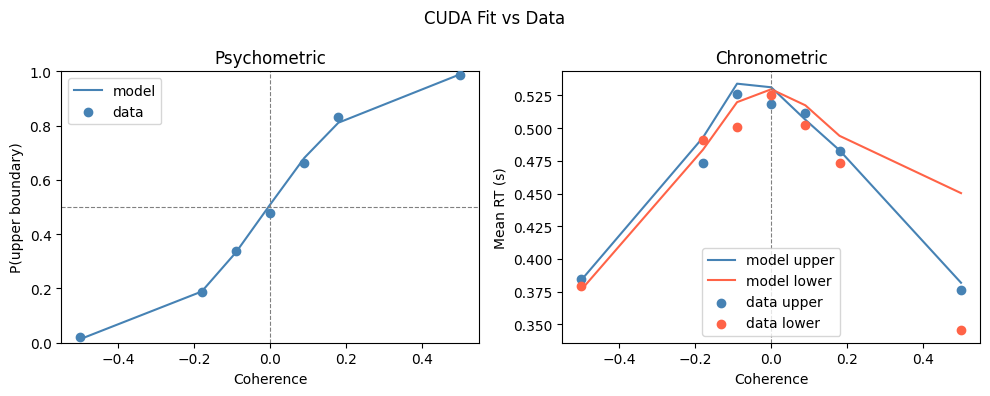

In [39]:
plot_ddm_fit(sim_data_cuda, data, title="CUDA Fit vs Data")

# Trajectory Checking

In [8]:
# calculate likelihood for original parameters (before fitting) for comparison
original_params = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,

}

stimulus = make_stimulus()

simple_model = SimpleModel()


data = pd.DataFrame(simple_model.simulate(
    stimulus, params=original_params, n_reps=10, seed=0
))

# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()


# data likelihood under original parameters
likelihood = simple_model.likelihood_calc.calculate_likelihood(
    data["rt"], data["choice"],
    data["rt"], data["choice"],
    data["coherence"], data["coherence"],
)

print(f"Data likelihood under original parameters: {likelihood:.1f}")


# print(summary)

# plot_mean_data(data)
# plot_raw_data(data)

INFO:src.ddm.ddm_simple:Initialized SimpleModel | device=CPU


Data likelihood under original parameters: 0.0


In [28]:
class DriftDiffusionSimulatorCUDA:
    """
    PyTorch GPU/CPU simulator.

    No-leak path: fully vectorized — cumsum builds the entire evidence
    trajectory in one shot, argmax finds the first boundary crossing.
    No Python loop over timesteps.

    Leak path: falls back to the sequential loop (leak couples timesteps,
    breaking the cumsum decomposition).
    """

    def __init__(self, device: str | None = None):
        if device == "cuda" and not torch.cuda.is_available():
            logger.warning("CUDA requested but unavailable, falling back to CPU.")
            device = "cpu"
        self.device = torch.device(
            device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        )
        logger.info("Using device: %s", self.device)

    def simulate_trials(
        self, stimulus: np.ndarray | torch.Tensor, params: dict
    ) -> tuple[np.ndarray, np.ndarray]:
        dev = self.device
        if isinstance(stimulus, torch.Tensor):
            stim = stimulus.to(dev, dtype=torch.float32)
        else:
            # Cache the GPU tensor: during fitting the same numpy array is passed
            # thousands of times. Re-uploading it on every call is the main GPU
            # bottleneck. We key the cache on the array's data pointer + shape.
            ptr = stimulus.__array_interface__["data"][0]
            key = (ptr, stimulus.shape)
            if getattr(self, "_stim_cache_key", None) != key:
                self._stim_cache_key = key
                self._stim_cache     = torch.tensor(stimulus, device=dev, dtype=torch.float32)
            stim = self._stim_cache
        n_trials, n_timepoints = stim.shape
        T = n_timepoints - 1

        a             = float(params["a"])
        z             = float(params["z"])
        ndt           = float(params["ndt"])
        drift_gain    = float(params["drift_gain"])
        drift_offset  = float(params["drift_offset"])
        variance      = float(params["variance"])
        dt            = float(params["dt"])
        leak_rate     = float(params["leak_rate"])
        time_constant = float(params["time_constant"])

        sp        = z * a
        noise_std = (variance * dt) ** 0.5

        # valid[i]: step t=i+1 is live (stim not NaN)
        valid     = ~torch.isnan(stim[:, 1:])                                 # (N, T)
        drift_inc = torch.nan_to_num((drift_gain * stim[:, :-1] + drift_offset) * dt)  # (N, T)
        noise_inc = torch.randn(n_trials, T, device=dev) * noise_std          # (N, T)

        if leak_rate == 0.0:
            # ------------------------------------------------------------------
            # No-leak: evidence is a simple cumsum of increments
            # ------------------------------------------------------------------
            evidence = sp + torch.cumsum((drift_inc + noise_inc) * valid, dim=1)
        else:
            # ------------------------------------------------------------------
            # Leak: e[t] = α·e[t-1] + b[t],  α = 1 − leak·dt
            #
            # Closed-form solution via FFT convolution (no Python time loop):
            #   e[t] = αᵗ·sp  +  Σ_{j=0}^{t-1} α^{t-1-j} · b[j]
            #        = αᵗ·sp  +  (b ★ w)[t-1]   where w[k] = αᵏ
            #
            # Crossing detection uses valid mask so the decaying evidence
            # after a NaN stimulus never triggers a false crossing.
            # ------------------------------------------------------------------
            α   = 1.0 - leak_rate # * dt
            # forcing term includes the leak's pull toward sp
            # b   = (drift_inc + noise_inc + sp * leak_rate * dt) * valid       # (N, T)
            b   = (drift_inc + noise_inc + sp * leak_rate * 1) * valid       # (N, T)

            fft_n = 1 << (2 * T - 1).bit_length()   # next power-of-2 ≥ 2T-1
            k     = torch.arange(T, device=dev, dtype=torch.float32)
            w     = torch.tensor(α, device=dev, dtype=torch.float32).pow(k)   # (T,)

            particular = torch.fft.irfft(
                torch.fft.rfft(b, n=fft_n, dim=1) * torch.fft.rfft(w, n=fft_n),
                n=fft_n, dim=1,
            )[:, :T]                                                           # (N, T)

            t_exp    = torch.arange(1, T + 1, device=dev, dtype=torch.float32)
            evidence = torch.tensor(α, device=dev).pow(t_exp) * sp + particular  # (N, T)

        if time_constant != 0.0:
            t_idx        = torch.arange(1, n_timepoints, device=dev, dtype=torch.float32)
            decision_var = sp + (evidence - sp) * (1.0 + t_idx * dt * time_constant)
        else:
            decision_var = evidence

        upper   = (decision_var >= a) & valid
        lower   = (decision_var <= 0) & valid
        crossed = upper | lower

        rt     = torch.full((n_trials,), float("nan"), device=dev, dtype=torch.float32)
        choice = torch.full((n_trials,), float("nan"), device=dev, dtype=torch.float32)

        has_crossed = crossed.any(dim=1)
        if has_crossed.any():
            first_idx       = crossed[has_crossed].int().argmax(dim=1)
            rt[has_crossed] = (first_idx.float() + 1) * dt + ndt
            choice[has_crossed] = (
                upper[has_crossed]
                .gather(1, first_idx.unsqueeze(1))
                .squeeze(1)
                .float()
            )

        return rt.cpu().numpy(), choice.cpu().numpy()

In [40]:
def simulate_with_trajectories(params, coherences, n_per_coh=5, max_duration=MAX_DURATION, seed=0):
    """Re-run DDM simulation and return full evidence trajectories alongside rt/choice."""
    torch.manual_seed(seed)

    dt            = float(params.get("dt", DT))
    a             = float(params["a"])
    z             = float(params["z"])
    ndt           = float(params["ndt"])
    drift_gain    = float(params["drift_gain"])
    drift_offset  = float(params.get("drift_offset", 0.0))
    variance      = float(params.get("variance", 1.0))
    leak_rate     = float(params.get("leak_rate", 0.0))
    time_constant = float(params.get("time_constant", 0.0))

    n_tp     = int(max_duration / dt)
    coh_arr  = np.repeat(np.array(coherences, dtype=np.float32), n_per_coh)
    stim_t   = torch.tensor(
        np.tile(coh_arr.reshape(-1, 1), (1, n_tp)), dtype=torch.float32
    )
    N, n_timepoints = stim_t.shape
    T = n_timepoints - 1

    sp        = z * a
    noise_std = (variance * dt) ** 0.5

    valid     = ~torch.isnan(stim_t[:, 1:])
    drift_inc = torch.nan_to_num((drift_gain * stim_t[:, :-1] + drift_offset) * dt)
    noise_inc = torch.randn(N, T) * noise_std

    if leak_rate == 0.0:
        evidence = sp + torch.cumsum((drift_inc + noise_inc) * valid, dim=1)
    else:
        alpha = 1.0 - leak_rate * dt
        b     = (drift_inc + noise_inc + sp * leak_rate * dt) * valid
        fft_n = 1 << (2 * T - 1).bit_length()
        k     = torch.arange(T, dtype=torch.float32)
        w     = torch.tensor(alpha).pow(k)
        particular = torch.fft.irfft(
            torch.fft.rfft(b, n=fft_n, dim=1) * torch.fft.rfft(w, n=fft_n),
            n=fft_n, dim=1,
        )[:, :T]
        t_exp    = torch.arange(1, T + 1, dtype=torch.float32)
        evidence = torch.tensor(alpha).pow(t_exp) * sp + particular

    if time_constant != 0.0:
        t_idx        = torch.arange(1, n_timepoints, dtype=torch.float32)
        decision_var = sp + (evidence - sp) * (1.0 + t_idx * dt * time_constant)
    else:
        decision_var = evidence

    upper   = (decision_var >= a) & valid
    lower   = (decision_var <= 0) & valid
    crossed = upper | lower

    rt     = np.full(N, np.nan)
    choice = np.full(N, np.nan)
    has_crossed = crossed.any(dim=1).numpy()
    if has_crossed.any():
        first_idx = crossed[has_crossed].int().argmax(dim=1).numpy()
        rt[has_crossed]     = (first_idx + 1) * dt + ndt
        choice[has_crossed] = (
            upper[has_crossed]
            .gather(1, torch.tensor(first_idx[:, None]))
            .squeeze(1).float().numpy()
        )

    # prepend starting point so trajectories[i, 0] == sp
    trajectories = torch.cat(
        [torch.full((N, 1), sp), decision_var], dim=1
    ).numpy()

    return dict(
        trajectories=trajectories,
        coherences=coh_arr,
        rt=rt,
        choice=choice,
        t=np.arange(n_timepoints) * dt,
        a=a,
        sp=sp,
        dt=dt,
        ndt=ndt,
    )


def plot_trajectories(params, coherences=COHERENCES, n_per_coh=8, seed=42, max_t=1.5):
    res   = simulate_with_trajectories(params, coherences, n_per_coh=n_per_coh, seed=seed)
    traj  = res["trajectories"]       # (N, n_tp)
    t     = res["t"]
    cohs  = res["coherences"]
    rt    = res["rt"]
    choice = res["choice"]
    a     = res["a"]
    sp    = res["sp"]
    dt    = res["dt"]

    t_mask = t <= max_t
    t_plot = t[t_mask]

    n_cohs = len(coherences)
    ncols  = min(4, n_cohs)
    nrows  = int(np.ceil(n_cohs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows), sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for idx, coh in enumerate(sorted(coherences)):
        ax   = axes[idx // ncols, idx % ncols]
        mask = np.round(cohs, 2) == round(coh, 2)

        for traj_i, rt_i, ch_i in zip(traj[mask], rt[mask], choice[mask]):
            if np.isfinite(rt_i):
                cross_step = min(int((rt_i - res["ndt"]) / dt) + 2, len(t))
                x = t[:cross_step][t[:cross_step] <= max_t]
                y = traj_i[:len(x)]
            else:
                x, y = t_plot, traj_i[t_mask]

            color = "steelblue" if ch_i == 1.0 else ("tomato" if ch_i == 0.0 else "gray")
            ax.plot(x, y, color=color, alpha=0.55, linewidth=0.9)

        ax.axhline(a,  color="k",    linestyle="--", linewidth=1.0)
        ax.axhline(0,  color="k",    linestyle="--", linewidth=1.0)
        ax.axhline(sp, color="gray", linestyle=":",  linewidth=0.8)
        ax.set_title(f"coh = {coh:+.2f}")
        ax.set_xlabel("Time (s)")
        # ax.set_xlim(0, max_t)
        ax.set_ylim(-0.15, a + 0.15)
        if idx % ncols == 0:
            ax.set_ylabel("Evidence")

    print(f"Mean RTs by coherence:")
    for coh in sorted(coherences):
        mask = np.round(cohs, 2) == round(coh, 2)
        mean_rt = np.nanmean(rt[mask])
        print(f"  coh = {coh:+.2f}: {mean_rt:.3f} s")

    # hide any unused axes
    for idx in range(n_cohs, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    # legend
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color="steelblue", label="upper boundary hit"),
        Line2D([0], [0], color="tomato",    label="lower boundary hit"),
        Line2D([0], [0], color="gray",      label="no decision"),
        Line2D([0], [0], color="k", linestyle="--", label="boundaries"),
        Line2D([0], [0], color="gray", linestyle=":", label="start point"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=5,
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle("Evidence Accumulation Trajectories", y=1.01)
    plt.tight_layout()
    plt.show()


Mean RTs by coherence:
  coh = +0.50: 0.375 s


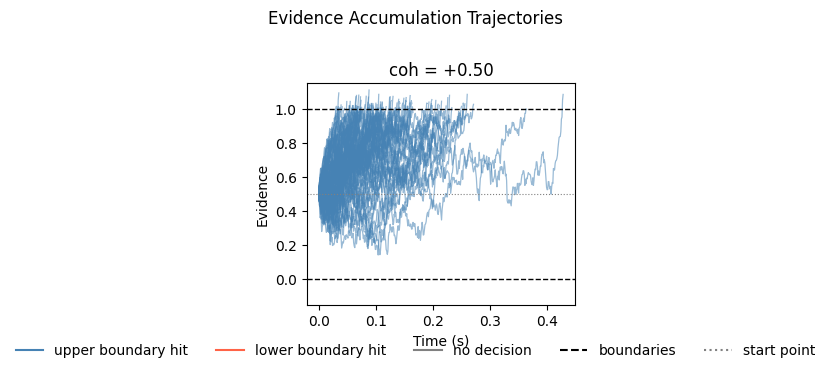

Mean RTs by coherence:
  coh = +0.50: 0.375 s


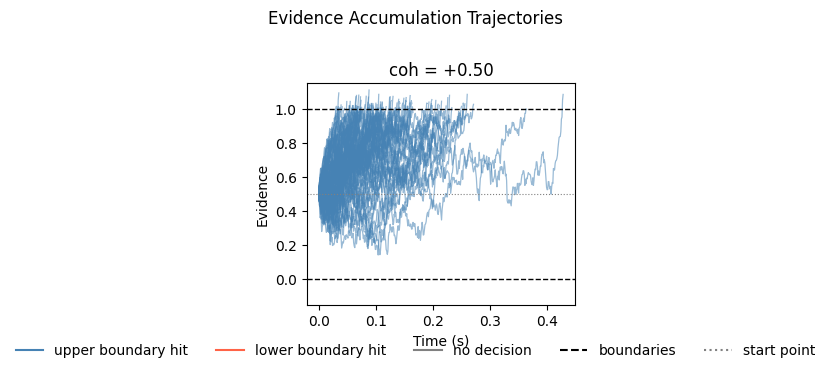

In [42]:

param_1 = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.01,
    "time_constant": 0,#0.5,
    "dt": 0.001,
}


param_2 = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.01,
    "time_constant": 0,#0.5,
    "dt": 0.001,
}
plot_trajectories(param_1, coherences=[0.5], n_per_coh=100)
plot_trajectories(param_2, coherences=[0.5], n_per_coh=100)